In [10]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob as glob
import os
import random
import seaborn as sns



In [11]:
DATA_DIR = r"C:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\dataset\Spunta\leaf_images\RGBFilter\channels_pgm"



# Map parts of filenames to classes
CLASS_MAP = {
    'healthybox': 'healthy',
    'unhealthybox': 'unhealthy',
    'unhealthy_boxes_bladroll': 'bladroll'
}

def get_label_from_filename(filename):
    filename_lower = filename.lower()
    # Order matters: longer/more specific substrings first
    for key in sorted(CLASS_MAP.keys(), key=lambda x: -len(x)):
        if key in filename_lower:
            return CLASS_MAP[key]
    return 'unknown'



In [12]:
def load_channel_images(channel_prefix):
    # Glob pattern: matches any text before _<channel>patch_*.pgm
    pattern = os.path.join(DATA_DIR, f'*_{channel_prefix}patch_*.pgm')
    files = glob.glob(pattern)
    
    imgs = []
    labels = []
    for f in files:
        img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print("Failed to read:", f)
            continue
        imgs.append(img)
        labels.append(get_label_from_filename(f))
    
    # Print loaded counts
    class_counts = {lbl: labels.count(lbl) for lbl in set(labels)}
    print(f"{channel_prefix} channel -> total images: {len(imgs)}, distribution: {class_counts}")
    
    return imgs, labels

In [13]:
# Load all channels
channels = ['R', 'G', 'B', 'H', 'S', 'V']
channel_data = {}
for c in channels:
    imgs, labels = load_channel_images(c)
    channel_data[c] = (imgs, labels)


R channel -> total images: 3928, distribution: {'unhealthy': 733, 'bladroll': 59, 'healthy': 3136}
G channel -> total images: 3928, distribution: {'unhealthy': 733, 'bladroll': 59, 'healthy': 3136}
B channel -> total images: 3928, distribution: {'unhealthy': 733, 'bladroll': 59, 'healthy': 3136}
H channel -> total images: 3928, distribution: {'unhealthy': 733, 'bladroll': 59, 'healthy': 3136}
S channel -> total images: 3928, distribution: {'unhealthy': 733, 'bladroll': 59, 'healthy': 3136}
V channel -> total images: 3928, distribution: {'unhealthy': 733, 'bladroll': 59, 'healthy': 3136}


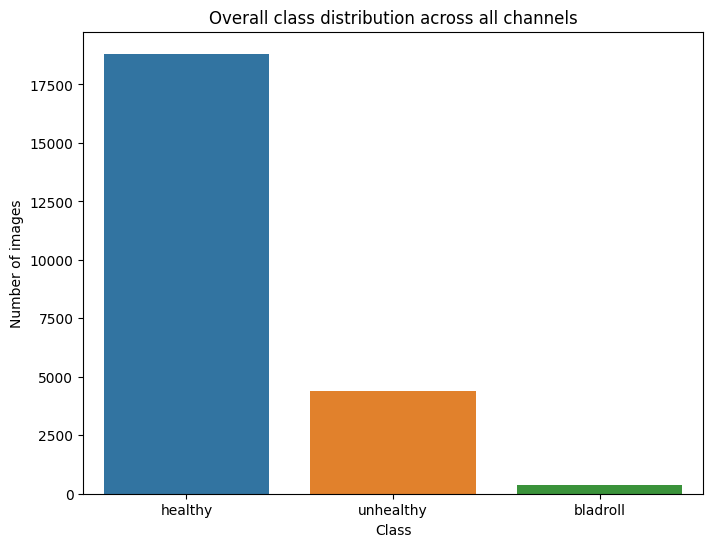

In [14]:
all_labels = []
for c in channels:
    _, labels = channel_data[c]
    all_labels.extend(labels)

# Count plot for overall distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=all_labels, order=['healthy', 'unhealthy', 'bladroll'])
plt.title('Overall class distribution across all channels')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.show()

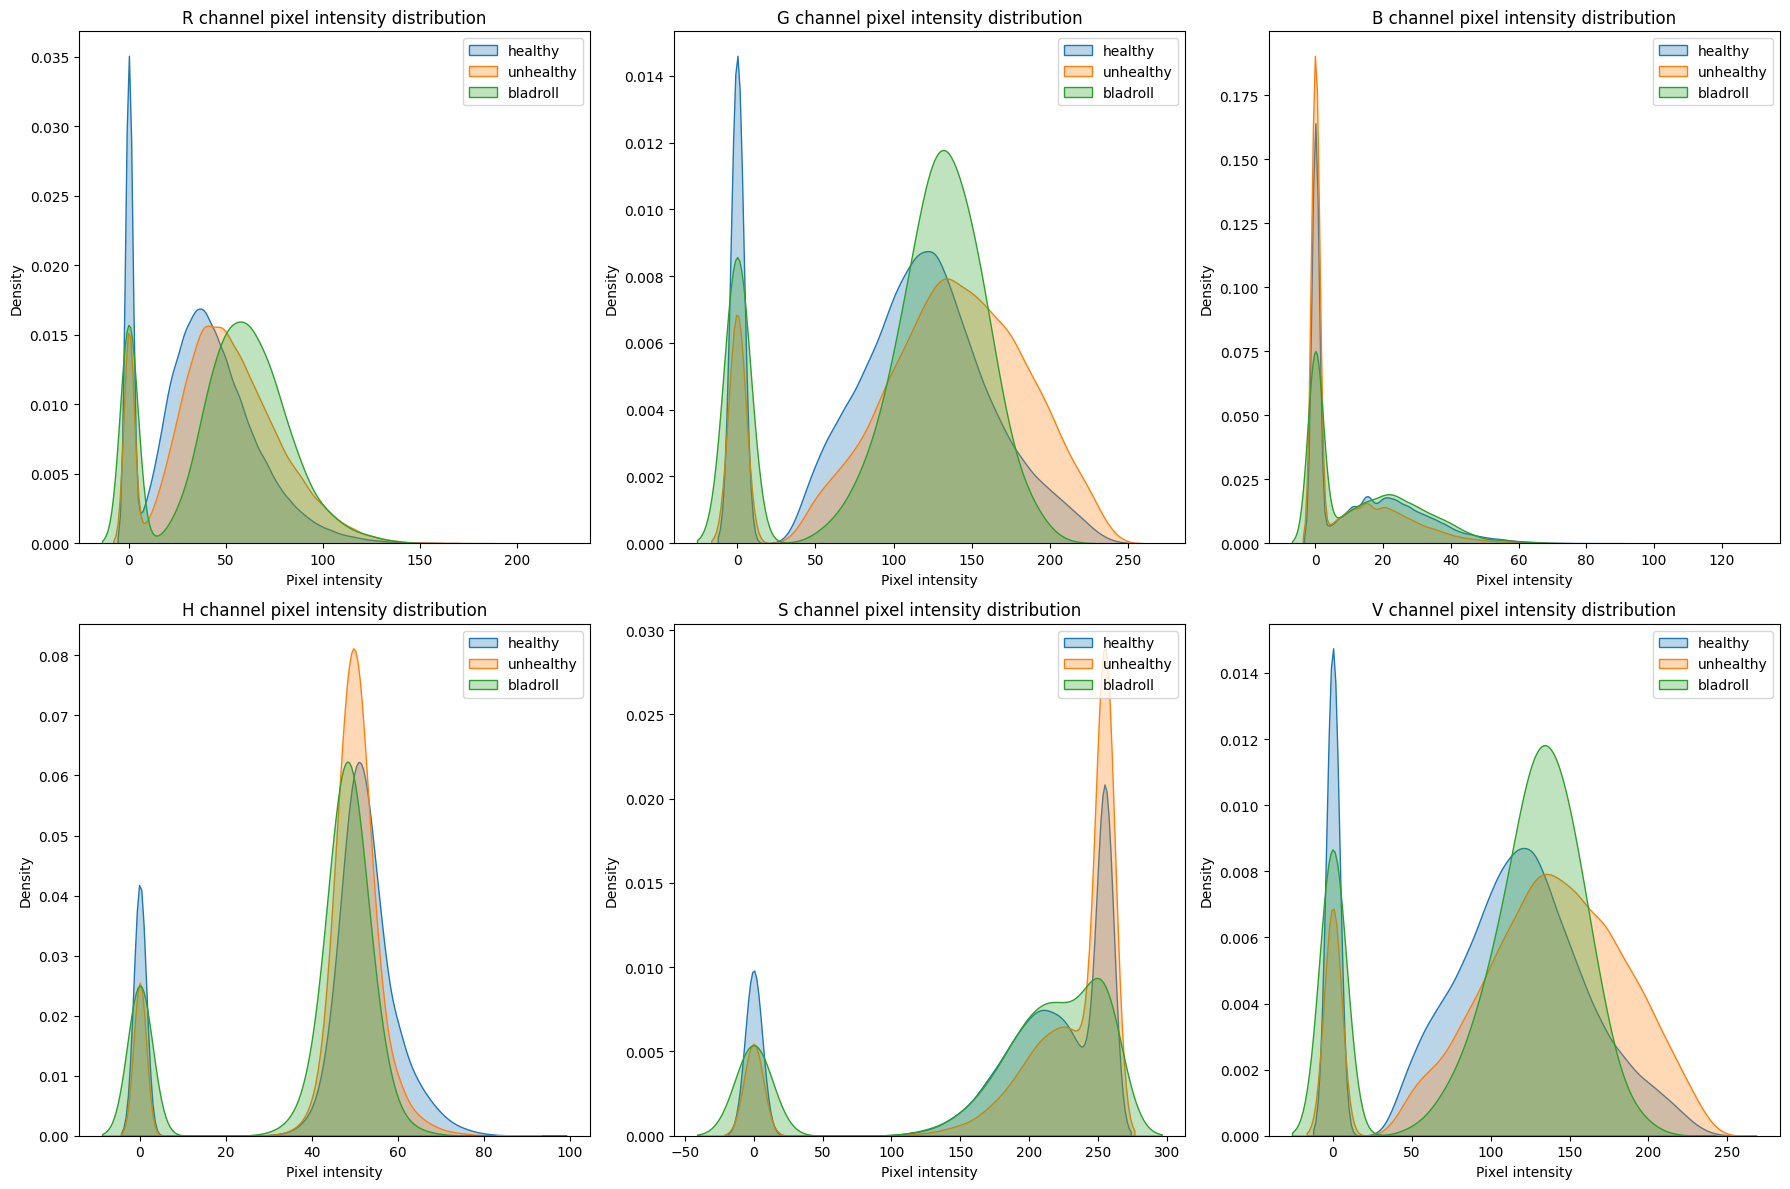

In [15]:


# Number of pixels to sample per class
PIXEL_SAMPLE = 500000  

plt.figure(figsize=(18, 12))

for i, c in enumerate(channels):
    imgs, labels = channel_data[c]
    plt.subplot(2, 3, i+1)
    
    # Storage for sampled pixels
    class_pixels = {'healthy': [], 'unhealthy': [], 'bladroll': []}

    for img, lbl in zip(imgs, labels):
        if lbl in class_pixels:
            flat = img.flatten()

            n_sample = len(flat) // 100  # 1% of pixels 
            sampled = np.random.choice(flat, n_sample, replace=False)
            class_pixels[lbl].extend(sampled)

    # Now downsample final pools
    for lbl in class_pixels:
        if len(class_pixels[lbl]) > PIXEL_SAMPLE:
            class_pixels[lbl] = random.sample(class_pixels[lbl], PIXEL_SAMPLE)

    # Plot KDE for each class
    for lbl, pixels in class_pixels.items():
        if len(pixels) > 0:
            sns.kdeplot(pixels, label=lbl, fill=True, alpha=0.3)

    plt.title(f'{c} channel pixel intensity distribution')
    plt.xlabel('Pixel intensity')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()
